## Occupation-Level Dataset

Job postings are grouped by NOC occupation. Each occupation is described using its number of postings, advertised vacancies, median hourly salary, and salary-data coverage.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

In [5]:
processed_path = Path(
    "../data/processed/job_bank_jan_2025_clean.parquet"
)

jobs = pd.read_parquet(processed_path)

print(f"Rows: {len(jobs):,}")
print(f"Columns: {jobs.shape[1]}")

Rows: 101,570
Columns: 68


In [6]:
# Only use valid salaries when calculating the median salary
jobs["clustering_salary"] = jobs["hourly_salary_midpoint"].where(
    jobs["salary_valid_for_analysis"]
)

occupation_summary = (
    jobs
    .dropna(subset=["noc21_code_name"])
    .groupby("noc21_code_name")
    .agg(
        posting_count=(
            "wic_job_location_snapshot_id",
            "count"
        ),
        total_vacancies=(
            "vacancy_count",
            "sum"
        ),
        valid_salary_postings=(
            "clustering_salary",
            "count"
        ),
        median_hourly_salary=(
            "clustering_salary",
            "median"
        )
    )
    .reset_index()
)

occupation_summary["salary_coverage_percentage"] = (
    occupation_summary["valid_salary_postings"]
    / occupation_summary["posting_count"]
    * 100
).round(1)

occupation_summary.head()

,noc21_code_name,posting_count,total_vacancies,valid_salary_postings,median_hourly_salary,salary_coverage_percentage
0,Accommodation service managers,77,83,61,31.000000,79.2
1,"Accommodation, travel, tourism and related ser...",102,124,100,26.502404,98.0
2,Accounting and related clerks,848,872,475,23.500000,56.0
3,Accounting technicians and bookkeepers,1223,1301,1006,28.500000,82.3
4,"Actors, comedians and circus performers",3,3,3,30.000000,100.0


In [7]:
clustering_data = occupation_summary[
    (occupation_summary["posting_count"] >= 20)
    & occupation_summary["median_hourly_salary"].notna()
].copy()

print(f"Occupations available: {len(clustering_data)}")

clustering_data.sort_values(
    "posting_count",
    ascending=False
).head(10)

Occupations available: 335


,noc21_code_name,posting_count,total_vacancies,valid_salary_postings,median_hourly_salary,salary_coverage_percentage
401,Retail salespersons and visual merchandisers,6381,6688,1503,20.500000,23.6
308,Other customer and information services repres...,3141,3427,623,20.913462,19.8
101,Cooks,2931,5161,2465,19.000000,84.1
167,Food service supervisors,2418,5112,2272,18.650000,94.0
5,Administrative assistants,2281,2478,1751,25.640000,76.8
398,Retail and wholesale buyers,2166,2194,145,18.000000,6.7
475,Transport truck drivers,2143,4671,1096,29.250000,51.1
322,Other sales related occupations,2052,2105,138,26.442308,6.7
399,Retail and wholesale trade managers,1933,1972,489,30.000000,25.3
6,Administrative officers,1724,2133,1116,28.850000,64.7


## Selecting the Number of Clusters

The clustering uses four occupation characteristics:

- Number of job postings
- Total advertised vacancies
- Median advertised hourly salary
- Percentage of postings containing valid salary information

The features are standardized before K-means clustering because they use different measurement scales.

In [8]:
cluster_features = clustering_data[
    [
        "posting_count",
        "total_vacancies",
        "median_hourly_salary",
        "salary_coverage_percentage"
    ]
].copy()

scaler = StandardScaler()

standardized_features = scaler.fit_transform(
    cluster_features
)

standardized_features = pd.DataFrame(
    standardized_features,
    columns=cluster_features.columns,
    index=cluster_features.index
)

standardized_features.head()

,posting_count,total_vacancies,median_hourly_salary,salary_coverage_percentage
0,-0.396265,-0.423382,-0.105163,0.798589
1,-0.351465,-0.369973,-0.414178,1.530059
2,0.985377,0.604411,-0.620464,-0.104076
3,1.657382,1.163249,-0.276930,0.919204
5,3.553332,2.696472,-0.473431,0.705210


In [9]:
cluster_ks = pd.DataFrame(
    columns=["k", "wssd"]
)

for k in range(1, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(standardized_features)

    current_k = pd.DataFrame({
        "k": [k],
        "wssd": [kmeans.inertia_]
    })

    cluster_ks = pd.concat(
        [cluster_ks, current_k],
        ignore_index=True
    )

cluster_ks

,k,wssd
0,1,1340.0
1,2,1067.891191
2,3,680.542444
3,4,534.148309
4,5,419.432953
5,6,357.523091
6,7,325.896947
7,8,264.524


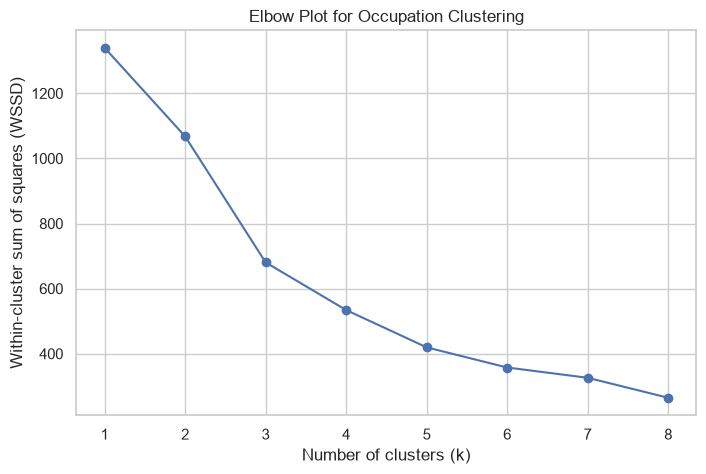

In [11]:
# Convert the chart columns to numbers
cluster_ks["k"] = cluster_ks["k"].astype(int)
cluster_ks["wssd"] = cluster_ks["wssd"].astype(float)

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_ks["k"],
    cluster_ks["wssd"],
    marker="o"
)

plt.title("Elbow Plot for Occupation Clustering")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares (WSSD)")
plt.xticks(range(1, 9))
plt.grid(True)

elbow_figure_path = Path(
    "../reports/figures/occupation_clustering_elbow.png"
)

plt.savefig(
    elbow_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Elbow-Method Result

The within-cluster sum of squares decreases substantially between one and three clusters. After three clusters, the improvements become more gradual. Therefore, three clusters were selected for the final K-means model.

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit(
    standardized_features
)

clustering_data["cluster"] = clusters.labels_

clustering_data[
    [
        "noc21_code_name",
        "posting_count",
        "total_vacancies",
        "median_hourly_salary",
        "salary_coverage_percentage",
        "cluster"
    ]
].head(10)

,noc21_code_name,posting_count,total_vacancies,median_hourly_salary,salary_coverage_percentage,cluster
0,Accommodation service managers,77,83,31.000000,79.2,0
1,"Accommodation, travel, tourism and related ser...",102,124,26.502404,98.0,0
2,Accounting and related clerks,848,872,23.500000,56.0,0
3,Accounting technicians and bookkeepers,1223,1301,28.500000,82.3,0
5,Administrative assistants,2281,2478,25.640000,76.8,2
6,Administrative officers,1724,2133,28.850000,64.7,2
7,Administrators - post-secondary education and ...,23,23,45.141904,65.2,0
8,"Advertising, marketing and public relations ma...",650,669,35.683930,27.1,1
11,"Agricultural representatives, consultants and ...",61,65,31.105769,19.7,1
12,Agricultural service contractors and farm supe...,82,177,22.500000,93.9,0


In [13]:
cluster_summary = (
    clustering_data
    .groupby("cluster")
    .agg(
        occupation_count=(
            "noc21_code_name",
            "count"
        ),
        average_postings=(
            "posting_count",
            "mean"
        ),
        average_vacancies=(
            "total_vacancies",
            "mean"
        ),
        average_salary=(
            "median_hourly_salary",
            "mean"
        ),
        average_salary_coverage=(
            "salary_coverage_percentage",
            "mean"
        )
    )
    .round(1)
)

cluster_summary

,occupation_count,average_postings,average_vacancies,average_salary,average_salary_coverage
cluster,,,,,
0,187,184.4,287.3,28.5,76.5
1,134,242.8,275.6,39.2,34.7
2,14,2346.4,3287.4,22.8,50.3


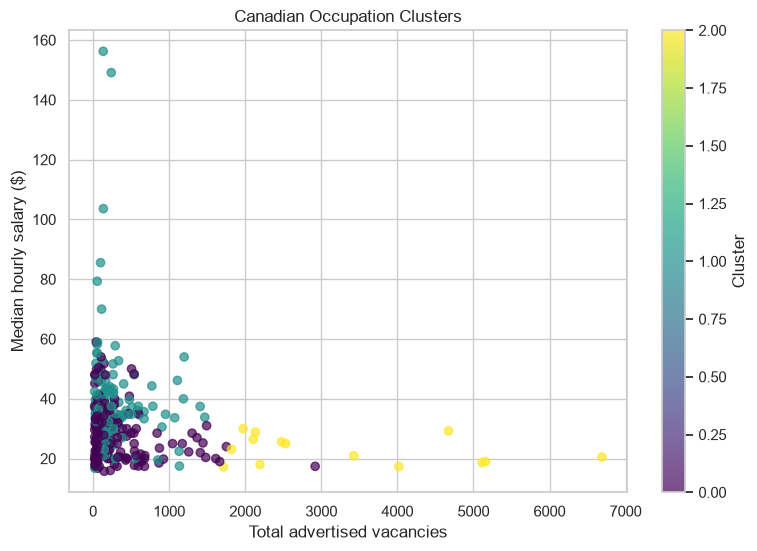

In [14]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    clustering_data["total_vacancies"],
    clustering_data["median_hourly_salary"],
    c=clustering_data["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.title("Canadian Occupation Clusters")
plt.xlabel("Total advertised vacancies")
plt.ylabel("Median hourly salary ($)")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)

cluster_figure_path = Path(
    "../reports/figures/occupation_clusters.png"
)

plt.savefig(
    cluster_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
cluster_summary

,occupation_count,average_postings,average_vacancies,average_salary,average_salary_coverage
cluster,,,,,
0,187,184.4,287.3,28.5,76.5
1,134,242.8,275.6,39.2,34.7
2,14,2346.4,3287.4,22.8,50.3


In [16]:
for cluster_number in [0, 1, 2]:
    print(f"\nCluster {cluster_number}")
    
    cluster_occupations = (
        clustering_data[
            clustering_data["cluster"] == cluster_number
        ]
        .sort_values(
            "total_vacancies",
            ascending=False
        )
        [
            [
                "noc21_code_name",
                "total_vacancies",
                "median_hourly_salary",
                "salary_coverage_percentage"
            ]
        ]
        .head(5)
    )
    
    display(cluster_occupations)


Cluster 0


,noc21_code_name,total_vacancies,median_hourly_salary,salary_coverage_percentage
189,Harvesting labourers,2919,17.400,98.5
291,"Nurse aides, orderlies and patient service ass...",1752,24.005,82.0
247,Light duty cleaners,1664,19.000,75.9
197,"Home support workers, caregivers and related o...",1613,20.000,62.8
59,Carpenters,1492,31.000,86.4



Cluster 1


,noc21_code_name,total_vacancies,median_hourly_salary,salary_coverage_percentage
38,"Automotive service technicians, truck and bus ...",1468,33.83,48.1
246,Licensed practical nurses,1407,37.44,51.4
343,Pharmacists,1197,54.00,11.3
391,Registered nurses and registered psychiatric n...,1187,40.00,20.9
434,"Store shelf stockers, clerks and order fillers",1135,17.50,9.8



Cluster 2


,noc21_code_name,total_vacancies,median_hourly_salary,salary_coverage_percentage
401,Retail salespersons and visual merchandisers,6688,20.50,23.6
101,Cooks,5161,19.00,84.1
167,Food service supervisors,5112,18.65,94.0
475,Transport truck drivers,4671,29.25,51.1
166,"Food counter attendants, kitchen helpers and r...",4020,17.35,83.2


In [17]:
cluster_names = {
    0: "Moderate demand, strong salary coverage",
    1: "Higher salary, limited salary coverage",
    2: "Very high demand, lower salary"
}

clustering_data["cluster_name"] = (
    clustering_data["cluster"]
    .map(cluster_names)
)

clustering_data[
    [
        "noc21_code_name",
        "total_vacancies",
        "median_hourly_salary",
        "salary_coverage_percentage",
        "cluster_name"
    ]
].head()

,noc21_code_name,total_vacancies,median_hourly_salary,salary_coverage_percentage,cluster_name
0,Accommodation service managers,83,31.000000,79.2,"Moderate demand, strong salary coverage"
1,"Accommodation, travel, tourism and related ser...",124,26.502404,98.0,"Moderate demand, strong salary coverage"
2,Accounting and related clerks,872,23.500000,56.0,"Moderate demand, strong salary coverage"
3,Accounting technicians and bookkeepers,1301,28.500000,82.3,"Moderate demand, strong salary coverage"
5,Administrative assistants,2478,25.640000,76.8,"Very high demand, lower salary"


In [18]:
cluster_output_path = Path(
    "../reports/occupation_clusters.csv"
)

clustering_data.to_csv(
    cluster_output_path,
    index=False
)

print(cluster_output_path.resolve())
print(cluster_output_path.exists())

C:\Users\vijda\OneDrive\Desktop\DSI_Class\repos\canadian-job-market-intelligence\reports\occupation_clusters.csv
True


## Conclusion

K-means clustering divided 335 Canadian occupations into three groups based on job postings, advertised vacancies, median hourly salary, and salary-data coverage.

**Cluster 0 — Moderate demand, strong salary coverage:**  
This was the largest cluster, containing 187 occupations. It had an average of 287 advertised vacancies per occupation, an average median salary of $28.50 per hour, and the highest salary coverage at 76.5%.

**Cluster 1 — Higher salary, limited salary coverage:**  
This cluster contained 134 occupations and had the highest average median salary at $39.20 per hour. However, only 34.7% of postings contained valid salary information. Examples included pharmacists, registered nurses, licensed practical nurses, and automotive service technicians.

**Cluster 2 — Very high demand, lower salary:**  
This was the smallest cluster, containing 14 occupations, but it had an average of 3,287 advertised vacancies per occupation. Its average median salary was $22.80 per hour. Examples included retail salespersons, cooks, food-service supervisors, transport truck drivers, and food-counter attendants.

The results indicate that occupations with the greatest hiring demand do not necessarily provide the highest advertised salaries. Higher-paying occupations generally appeared in a separate group with fewer vacancies and lower salary transparency.

The cluster names are descriptive interpretations of the results and are not official Canadian Job Bank classifications.